In [1]:
# Importing Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

d:\Developer\python_course_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import seaborn as sns

In [6]:
df_da_us = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_da_us = df_da_us.dropna(subset = ['salary_year_avg'])

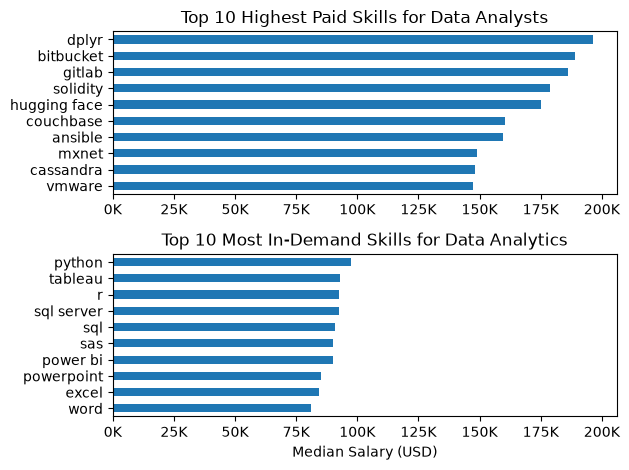

In [8]:
df_da_us = df_da_us.explode('job_skills')
df_da_us[['salary_year_avg', 'job_skills']]

df_da_us_group = df_da_us.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])

# DataFrame-1: Top 10 high salaries
df_da_top_pay = df_da_us_group.sort_values(by = 'median', ascending = False).head(10)

# DataFrame-2: Top 10 skills having the highest count
df_da_skills = df_da_us_group.sort_values(by='count', ascending = False).head(10).sort_values(by = 'median', ascending = False)

fig, ax = plt.subplots(2, 1)

df_da_top_pay[::-1].plot(kind = 'barh', y = 'median', ax = ax[0], legend = False)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

df_da_skills.plot(kind = 'barh', y = 'median', ax = ax[1], legend = False)
ax[1].invert_yaxis()
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analytics')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

plt.tight_layout()
plt.show()

## Bar Charts

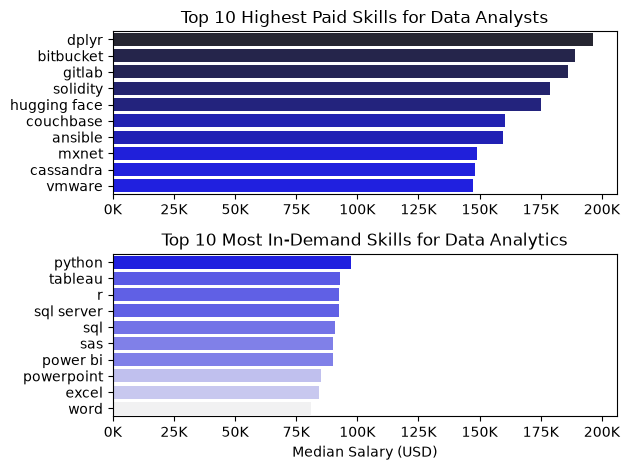

In [ ]:
fig, ax = plt.subplots(2, 1)

sns.barplot(data = df_da_top_pay, x = 'median', y = df_da_top_pay.index, ax = ax[0], hue = 'median', palette = 'dark:b_r', legend = False)

# df_da_top_pay[::-1].plot(kind = 'barh', y = 'median', ax = ax[0], legend = False)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

sns.barplot(data = df_da_skills, x = 'median', y = df_da_skills.index, ax = ax[1], hue = 'median', palette = 'light:b', legend = False)

# df_da_skills.plot(kind = 'barh', y = 'median', ax = ax[1], legend = False)
# ax[1].invert_yaxis()
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analytics')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

plt.tight_layout()
plt.show()

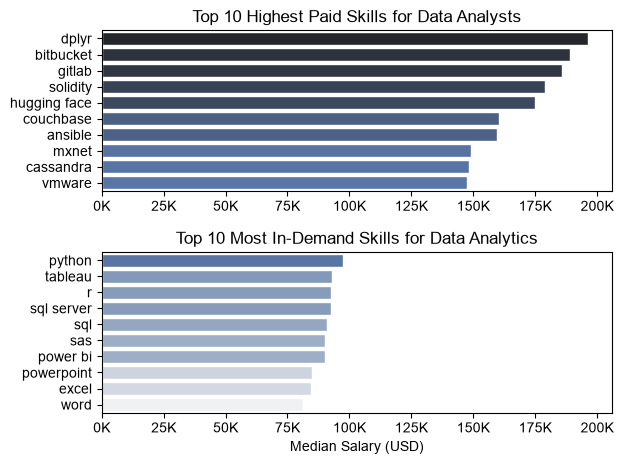

In [16]:
fig, ax = plt.subplots(2, 1)

sns.set_theme(style = 'ticks')

sns.barplot(data = df_da_top_pay, x = 'median', y = df_da_top_pay.index, ax = ax[0], hue = 'median', palette = 'dark:b_r', legend = False)

# df_da_top_pay[::-1].plot(kind = 'barh', y = 'median', ax = ax[0], legend = False)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

sns.barplot(data = df_da_skills, x = 'median', y = df_da_skills.index, ax = ax[1], hue = 'median', palette = 'light:b', legend = False)

# df_da_skills.plot(kind = 'barh', y = 'median', ax = ax[1], legend = False)
# ax[1].invert_yaxis()
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analytics')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

plt.tight_layout()
plt.show()

## Histograms

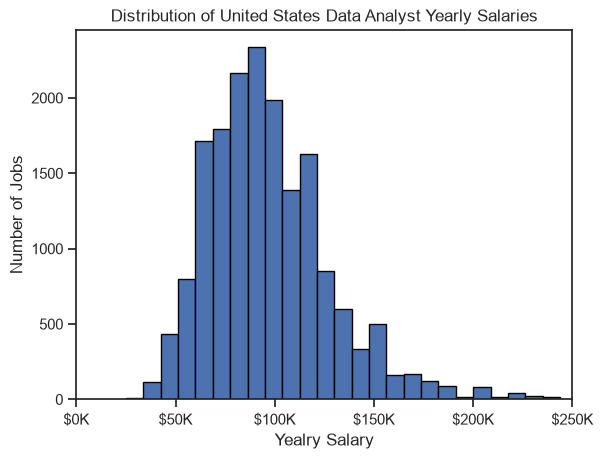

In [18]:
df_da_us['salary_year_avg'].plot(kind = 'hist', bins = 40, edgecolor = 'black')
plt.xlim(0, 250000)

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yealry Salary')
plt.ylabel('Number of Jobs')
plt.show()

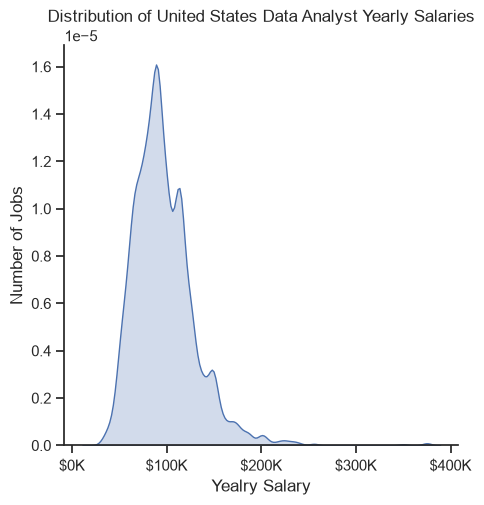

In [22]:
# kde: kernel density estimation
sns.displot(df_da_us['salary_year_avg'], kind = 'kde', fill = True)
sns.set_theme(style = 'ticks')
plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yealry Salary')
plt.ylabel('Number of Jobs')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
plt.show()

## Box Plots

C:\Users\Shivangi\AppData\Local\Temp\ipykernel_17924\2569018831.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(job_list, tick_labels = job_titles, vert = False)


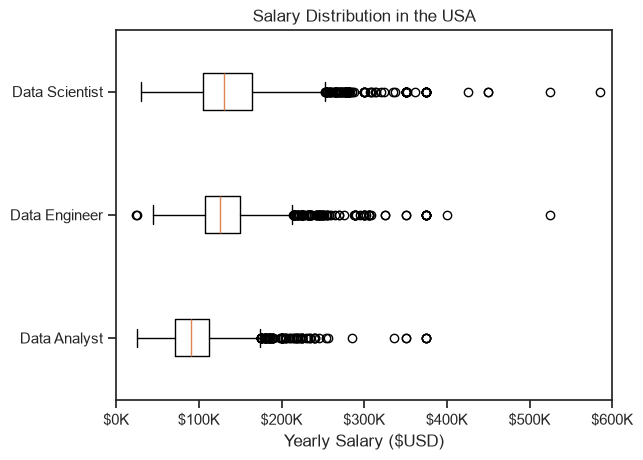

In [23]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()

df_US = df_US.dropna(subset = ['salary_year_avg'])

job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, tick_labels = job_titles, vert = False)

plt.title('Salary Distribution in the USA')
plt.xlabel('Yearly Salary ($USD)')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0, 600000)
plt.show()

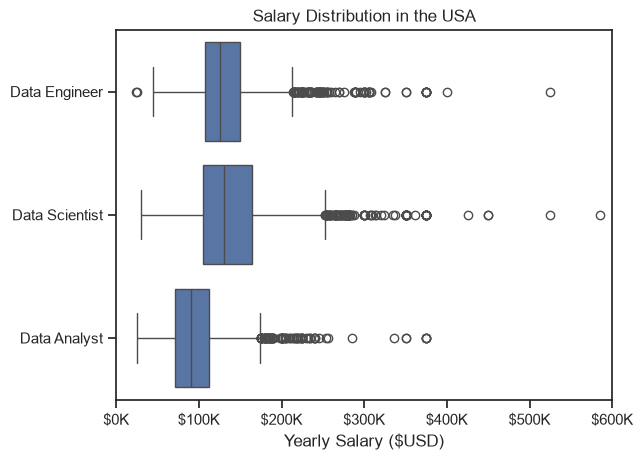

In [25]:
sns.boxplot(data = df_US, x = 'salary_year_avg', y = 'job_title_short')

plt.title('Salary Distribution in the USA')
plt.ylabel('')
plt.xlabel('Yearly Salary ($USD)')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0, 600000)
plt.show()